In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargamos solo la primera tabla (filas 4 a 16)
df = pd.read_csv('ipc_capitulos.csv',
                 sep=';',
                 skiprows=4,
                 nrows=12,
                 decimal=',')

# Limpiamos
df = df.dropna(how='all')
df.columns = ['Capitulo'] + list(df.columns[1:])
df = df[df['Capitulo'].notna()]
df = df[df['Capitulo'].str.strip() != '']
df = df.set_index('Capitulo')

# Convertimos todo a numérico
df = df.apply(pd.to_numeric, errors='coerce')

print(df.shape)
print(df.head())

(10, 8)
                                        abr-16  may-16  jun-16  jul-16  \
Capitulo                                                                 
Nivel general                            100.0   104.2   107.4   109.6   
Alimentos y Bebidas                      100.0   103.7   107.0   109.9   
Indumentaria                             100.0   102.3   102.5   101.8   
Vivienda y servicios básicos             100.0   105.2   112.6   113.6   
Equipamiento y mantenimiento del hogar   100.0   102.9   107.7   110.3   

                                        ago-16  sept-16  oct-16  nov-16  
Capitulo                                                                 
Nivel general                            109.8    111.1   113.7   115.5  
Alimentos y Bebidas                      110.6    113.1   114.8   117.0  
Indumentaria                             102.6    107.6   111.4   112.8  
Vivienda y servicios básicos             107.2    101.5   112.4   114.0  
Equipamiento y mantenimiento 

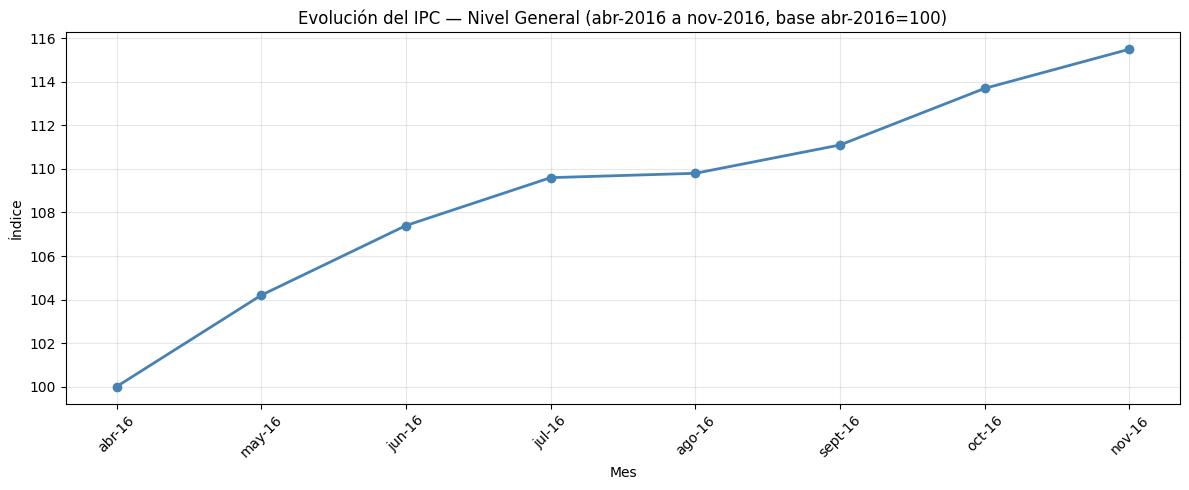

In [2]:
# Análisis 1: Evolución del Nivel General IPC
nivel_general = df.loc['Nivel general']

plt.figure(figsize=(12,5))
plt.plot(nivel_general.index, nivel_general.values, marker='o', color='steelblue', linewidth=2)
plt.title('Evolución del IPC — Nivel General (abr-2016 a nov-2016, base abr-2016=100)')
plt.xlabel('Mes')
plt.ylabel('Índice')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

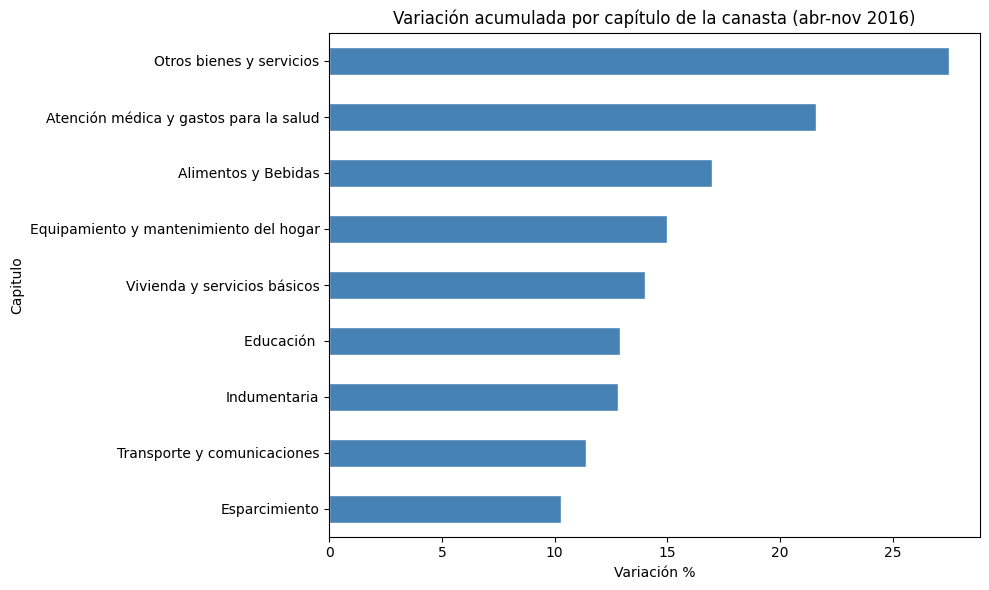

In [3]:
# Análisis 2: Variación por capítulo — cuál subió más
variacion = ((df.iloc[:, -1] - df.iloc[:, 0]) / df.iloc[:, 0] * 100).sort_values(ascending=False)
variacion = variacion.drop('Nivel general')

variacion.plot(kind='barh', figsize=(10,6), color='steelblue', edgecolor='white')
plt.title('Variación acumulada por capítulo de la canasta (abr-nov 2016)')
plt.xlabel('Variación %')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

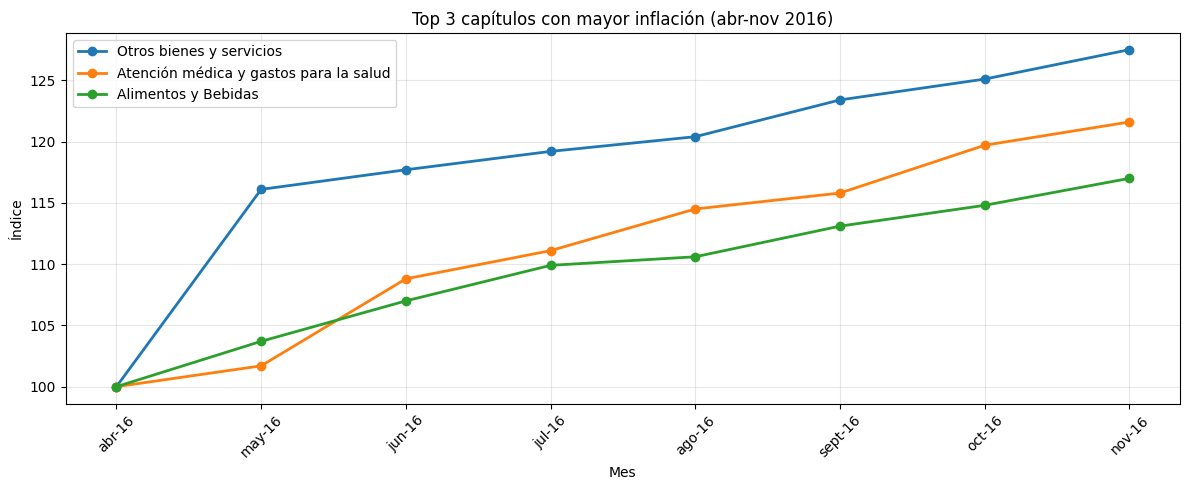

In [4]:
# Análisis 3: Evolución de los 3 capítulos que más subieron
top3 = variacion.head(3).index.tolist()

plt.figure(figsize=(12,5))
for cap in top3:
    plt.plot(df.columns, df.loc[cap], marker='o', linewidth=2, label=cap)

plt.title('Top 3 capítulos con mayor inflación (abr-nov 2016)')
plt.xlabel('Mes')
plt.ylabel('Índice')
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()